# Goal: Plot logical error rate against # rounds for different distances

probability should be chosen below threshold

In [35]:
import numpy as np

from tools.surface_code import generate_steane_circuit 
from tools.error_models import add_noise, construct_circuit_noise_model
from tools.log_error_rate import count_logical_errors_ML, count_logical_errors_MWPM

In [36]:
import tools.graphics as graphic 
from importlib import reload
reload(graphic)

<module 'tools.graphics' from '/home/leo/Documents/MasterArbeit/code/new_start/tools/graphics.py'>

In [37]:
import matplotlib.pyplot as plt

In [38]:
def generate_data(
        distances,
        rounds,
        p,
        count_logical_errors_func,
        num_shots: int = 10_000,
        noise_model_func = construct_circuit_noise_model,
        noise_model_string = "circ",
        ):
    noise_model = noise_model_func(p) 

    log_error_rates = np.zeros((len(distances),len(rounds)))
    err_log_error_rates = np.zeros((len(distances),len(rounds)))
    for i_d, d in enumerate(distances):
        for i_r, r in enumerate(rounds):
            n_circ = add_noise(
                circuit=generate_steane_circuit(distance=d, rounds=r), 
                noise_model=noise_model,
                )
            log_error_rates[i_d, i_r] = count_logical_errors_func(
                circuit=n_circ,
                distance=d,
                rounds=r,
                num_shots=num_shots,
                error_rate=p,
                noise_model=noise_model_string,
                observable="Z",
                probability=True,
            )
            err_log_error_rates[i_d, i_r] = (log_error_rates[i_d,i_r]*(1-log_error_rates[i_d,i_r])/num_shots)**(1/2) 
    return log_error_rates, err_log_error_rates

In [42]:
def plot(rounds,distances,log_error_rates,err_log_error_rates,title=""):
    plt.figure()
    plt.title(title)
    for i_d, d in enumerate(distances):
        plt.errorbar(
            rounds,
            log_error_rates[i_d],
            yerr=err_log_error_rates[i_d],
            label=f"$d={d}$",
        )
    plt.yscale("log")
    plt.legend()
    plt.xlabel("rounds")
    plt.ylabel("logical error rate")
        

In [ ]:
# MWPM
# TODO determine threshold !
mwpm_distances = [3,5,7,9]
mwpm_rounds = np.arange(1,40)
mwpm_p = 5*10**-3
count_logical_errors_func = count_logical_errors_MWPM

mwpm_log_p, mwpm_log_p_err = generate_data(
   distances=mwpm_distances,
   rounds=mwpm_rounds,
   p=mwpm_p, 
   count_logical_errors_func=count_logical_errors_func,
)

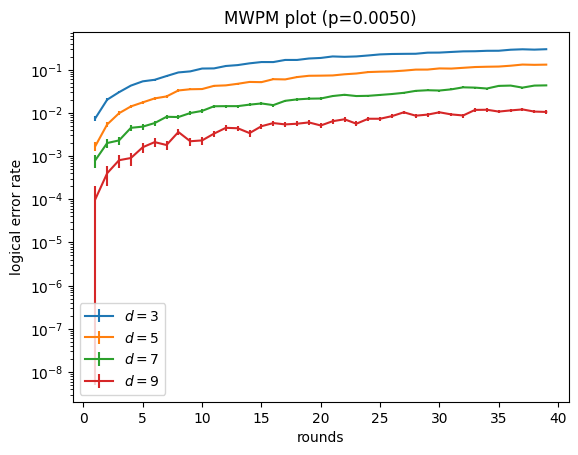

In [47]:
plot(
    rounds=mwpm_rounds,
    distances=mwpm_distances,
    log_error_rates=mwpm_log_p,
    err_log_error_rates=mwpm_log_p_err,
    title=f"MWPM plot (p={mwpm_p:.4f})"
    )

In [ ]:
# MWPM
# TODO determine threshold !
ml_distances = [3,5,7]
ml_rounds = np.arange(1,20)
ml_p = 5*10**-3
count_logical_errors_func = count_logical_errors_ML

ml_log_p, ml_log_p_err = generate_data(
   distances=mwpm_distances,
   rounds=mwpm_rounds,
   p=mwpm_p, 
   count_logical_errors_func=count_logical_errors_func,
)

In [ ]:
plot(
    rounds=ml_rounds,
    distances=ml_distances,
    log_error_rates=ml_log_p,
    err_log_error_rates=ml_log_p_err,
    title=f"MWPM plot (p={ml_p:.4f})"
    )